In [51]:
%pip install kagglehub pyarrow xgboost tensorflow scikit-learn tensorflow pandas imbalanced-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [52]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dhoogla/unswnb15")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Christopher Chong\.cache\kagglehub\datasets\dhoogla\unswnb15\versions\5



Training set shape: (175341, 36)
Testing set shape: (82332, 36)

--- Head ---


,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
0,0.121478,tcp,-,FIN,6,4,258,172,74.087486,14158.942383,...,0,0,1,1,0,0,0,0,Normal,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473373,8395.112305,...,0,0,1,1,0,0,0,0,Normal,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,1572.271851,...,0,0,1,1,0,0,0,0,Normal,0
3,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,2740.178955,...,0,0,1,1,1,1,0,0,Normal,0
4,0.449454,tcp,-,FIN,10,6,534,268,33.373825,8561.499023,...,0,0,2,1,0,0,0,0,Normal,0



--- Info ---
<class 'pandas.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 36 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   dur                175341 non-null  float32 
 1   proto              175341 non-null  category
 2   service            175341 non-null  category
 3   state              175341 non-null  category
 4   spkts              175341 non-null  int16   
 5   dpkts              175341 non-null  int16   
 6   sbytes             175341 non-null  int32   
 7   dbytes             175341 non-null  int32   
 8   rate               175341 non-null  float32 
 9   sload              175341 non-null  float32 
 10  dload              175341 non-null  float32 
 11  sloss              175341 non-null  int16   
 12  dloss              175341 non-null  int16   
 13  sinpkt             175341 non-null  float32 
 14  dinpkt             175341 non-null  float32 
 15  sjit               175341 non-n

Series([], dtype: int64)


--- Duplicate rows ---
78519

--- Numeric summary ---


...

,count,unique,top,freq
proto,175341,133,tcp,79946
service,175341,13,-,94168
state,175341,9,INT,82275
attack_cat,175341,10,Normal,56000



--- Value counts: label ---


label
1    119341
0     56000
Name: count, dtype: int64


--- Value counts: attack_cat ---


attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64

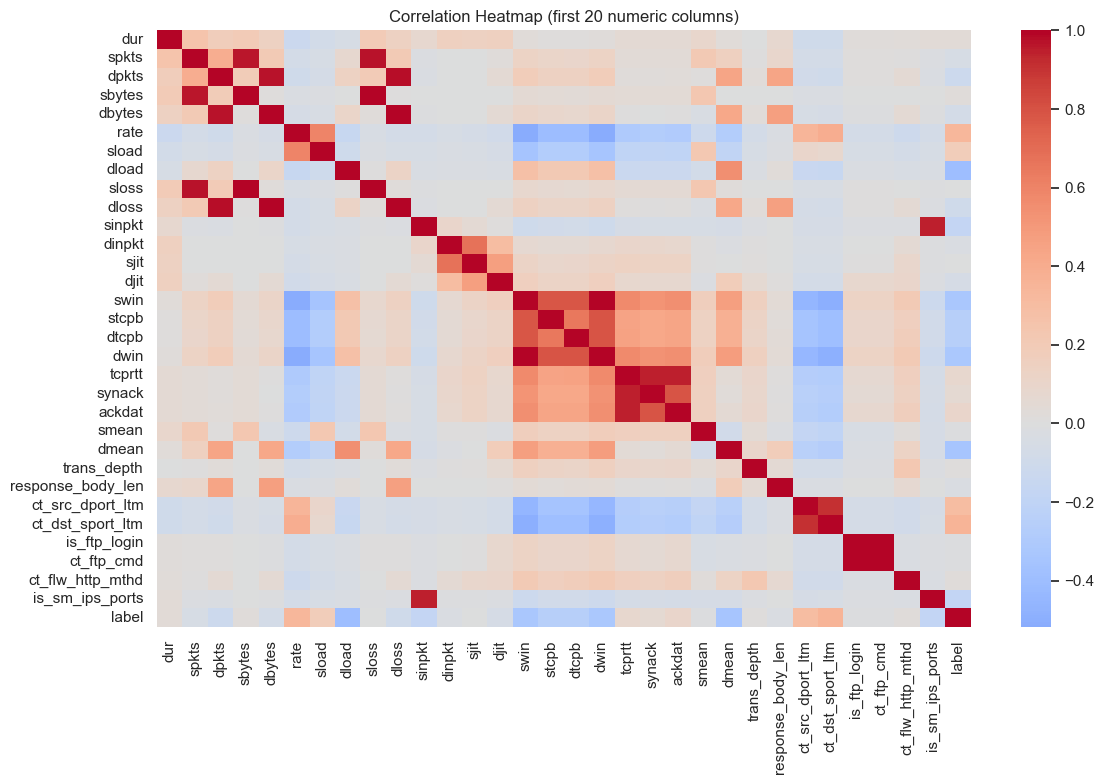

In [53]:
import os
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

test_df = pd.read_parquet(os.path.join(path, "UNSW_NB15_testing-set.parquet"))
train_df = pd.read_parquet(os.path.join(path, "UNSW_NB15_training-set.parquet"))

print("\nTraining set shape:", train_df.shape)
print("Testing set shape:", test_df.shape)

# Quick EDA of the training set
print("\n--- Head ---")
display(train_df.head())

print("\n--- Info ---")
train_df.info()

print("\n--- Missing values (top 20) ---")
missing = train_df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0].head(20))

print("\n--- Duplicate rows ---")
print(train_df.duplicated().sum())

print("\n--- Numeric summary ---")
display(train_df.describe(include=["number"]).T)

print("\n--- Categorical summary ---")
cat_cols = train_df.select_dtypes(include=["object", "category"]).columns
if len(cat_cols) > 0:
    display(train_df[cat_cols].describe().T.head(20))

# Target distribution
for target_col in ["label", "attack_cat", "Class", "class"]:
    if target_col in train_df.columns:
        print(f"\n--- Value counts: {target_col} ---")
        display(train_df[target_col].value_counts(dropna=False).head(20))

# Basic visual EDA
sns.set(style="whitegrid")

# Missing values plot (top 15)
top_missing = missing[missing > 0].head(15)
if not top_missing.empty:
    plt.figure(figsize=(10, 5))
    sns.barplot(x=top_missing.values, y=top_missing.index, palette="viridis")
    plt.title("Top Missing Columns")
    plt.xlabel("Missing Count")
    plt.ylabel("Column")
    plt.tight_layout()
    plt.show()

# Correlation heatmap for numeric columns
num_cols = train_df.select_dtypes(include=["number"]).columns
if len(num_cols) > 1:
    sample_num_cols = num_cols  # limit for readability
    corr = train_df[sample_num_cols].corr()
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr, cmap="coolwarm", center=0)
    plt.title("Correlation Heatmap (first 20 numeric columns)")
    plt.tight_layout()
    plt.show()

In [54]:
# Check null/NaN values in train and test sets
for name, df in [("train_df", train_df), ("test_df", test_df)]:
    null_counts = df.isna().sum()
    total_nulls = int(null_counts.sum())
    
    print(f"\n{name} -> total null/NaN values: {total_nulls}")
    print(f"{name} -> columns with null/NaN: {(null_counts > 0).sum()}")
    
    if total_nulls > 0:
        display(null_counts[null_counts > 0].sort_values(ascending=False))


train_df -> total null/NaN values: 0
train_df -> columns with null/NaN: 0

test_df -> total null/NaN values: 0
test_df -> columns with null/NaN: 0


In [55]:
from sklearn.preprocessing import StandardScaler

# Drop duplicate rows
train_before, test_before = len(train_df), len(test_df)
train_df = train_df.drop_duplicates().reset_index(drop=True)
test_df = test_df.drop_duplicates().reset_index(drop=True)

# Normalize numeric feature columns (fit on train, apply to test)
numeric_cols = train_df.select_dtypes(include="number").columns.tolist()
exclude_cols = {"label", "Class", "class"}
if "target" in globals():
    exclude_cols.add(target)

feature_cols = [c for c in numeric_cols if c not in exclude_cols and c in test_df.columns]

scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df[feature_cols].astype("float64"))
train_df[feature_cols] = pd.DataFrame(train_scaled, columns=feature_cols, index=train_df.index)
    
test_scaled = scaler.transform(test_df[feature_cols].astype("float64"))
test_df[feature_cols] = pd.DataFrame(test_scaled, columns=feature_cols, index=test_df.index)

print(f"Train duplicates removed: {train_before - len(train_df)}")
print(f"Test duplicates removed: {test_before - len(test_df)}")
print(f"Standardized feature count: {len(feature_cols)}")

Train duplicates removed: 78519
Test duplicates removed: 32361
Standardized feature count: 31


In [56]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix

target = "label"

train_df

y_train = train_df[target]
X_train = train_df.drop(columns=[target, "attack_cat"])

y_test = test_df[target]
X_test = test_df.drop(columns=[target, "attack_cat"])

# Baseline: always predict the most frequent class from training data
baseline_clf = DummyClassifier(strategy="most_frequent", random_state=42)
baseline_clf.fit(X_train, y_train)
y_pred = baseline_clf.predict(X_test)

print(f"Target column: {target}")
print(f"Baseline strategy: {baseline_clf.strategy}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred):.4f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred, zero_division=0))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

Target column: label
Baseline strategy: most_frequent
Accuracy: 0.6326
Balanced Accuracy: 0.5000

Classification report:
              precision    recall  f1-score   support

           0       0.63      1.00      0.77     31610
           1       0.00      0.00      0.00     18361

    accuracy                           0.63     49971
   macro avg       0.32      0.50      0.39     49971
weighted avg       0.40      0.63      0.49     49971

Confusion matrix:
[[31610     0]
 [18361     0]]


In [57]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import label_binarize

# One-hot encode categorical features and align train/test columns
X_train_enc = pd.get_dummies(X_train)
X_test_enc = pd.get_dummies(X_test)
X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join="left", axis=1, fill_value=0)

# Filter to the 4 attack types used in this study
attack_types = ['Generic', 'Reconnaissance', 'Backdoor', 'Normal']
train_mask = train_df['attack_cat'].isin(attack_types)
test_mask  = test_df['attack_cat'].isin(attack_types)

X_train_filtered = X_train_enc[train_mask]
y_train_filtered = train_df.loc[train_mask, 'attack_cat']

X_test_filtered = X_test_enc[test_mask]
y_test_filtered = test_df.loc[test_mask, 'attack_cat']

print("Class distribution in training set before SMOTE:")
print(y_train_filtered.value_counts().sort_index())


Class distribution in training set before SMOTE:
attack_cat
Analysis              0
Backdoor           1121
DoS                   0
Exploits              0
Fuzzers               0
Generic            1800
Normal            48894
Reconnaissance     6000
Shellcode             0
Worms                 0
Name: count, dtype: int64


In [58]:
from imblearn.over_sampling import SMOTE

# SMOTE only on training data , test set is never touched
# Generates synthetic minority-class samples by interpolating between
# existing samples in feature space, balancing all 4 attack classes
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_filtered, y_train_filtered)

print("Class distribution after SMOTE (training only):")
print(pd.Series(y_train_smote).value_counts().sort_index())
print(f"Training size: {len(X_train_filtered):,} → {len(X_train_smote):,}")
print("Test set unchanged:", y_test_filtered.value_counts().sort_index().to_dict())


Class distribution after SMOTE (training only):
attack_cat
Analysis              0
Backdoor          48894
DoS                   0
Exploits              0
Fuzzers               0
Generic           48894
Normal            48894
Reconnaissance    48894
Shellcode             0
Worms                 0
Name: count, dtype: int64
Training size: 57,815 → 195,576
Test set unchanged: {'Analysis': 0, 'Backdoor': 296, 'DoS': 0, 'Exploits': 0, 'Fuzzers': 0, 'Generic': 1643, 'Normal': 31610, 'Reconnaissance': 2127, 'Shellcode': 0, 'Worms': 0}


Attack Type Classification: RandomForestClassifier
Accuracy: 0.9771
Balanced Accuracy: 0.8974
Classification report:
                precision    recall  f1-score   support

      Backdoor       0.51      0.85      0.64       296
       Generic       0.87      0.92      0.89      1643
        Normal       0.99      0.99      0.99     31610
Reconnaissance       0.94      0.83      0.88      2127

      accuracy                           0.98     35676
     macro avg       0.83      0.90      0.85     35676
  weighted avg       0.98      0.98      0.98     35676

Confusion matrix:
[[  251    11    11    23]
 [   36  1506    84    17]
 [    5   199 31328    78]
 [  200    16   137  1774]]
ROC-AUC (macro OvR): 0.9917
PR-AUC  (macro OvR): 0.8303


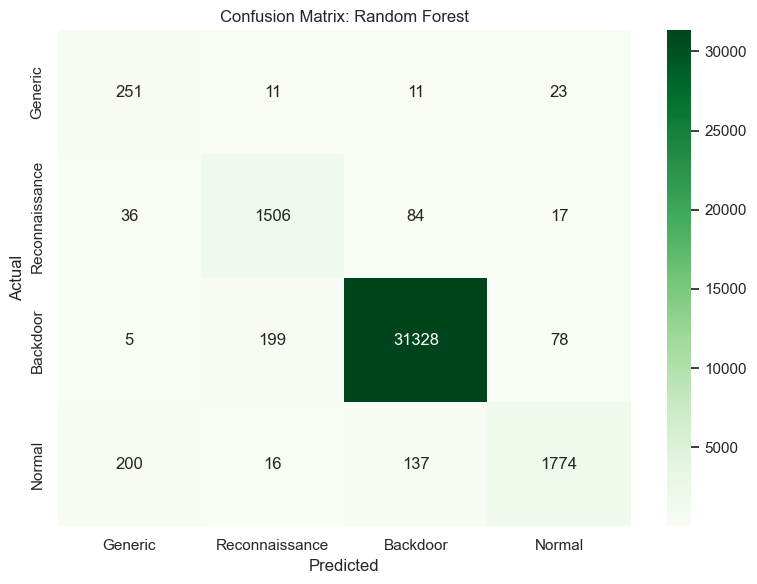

In [60]:
# Train Random Forest on SMOTE-balanced training data
rf_attack_clf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"   # kept as additional safeguard
)
rf_attack_clf.fit(X_train_smote, y_train_smote)

y_pred_attack = rf_attack_clf.predict(X_test_filtered)

print("Attack Type Classification: RandomForestClassifier")
print(f"Accuracy: {accuracy_score(y_test_filtered, y_pred_attack):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test_filtered, y_pred_attack):.4f}")
print("Classification report:")
print(classification_report(y_test_filtered, y_pred_attack, zero_division=0))

print("Confusion matrix:")
cm_attack = confusion_matrix(y_test_filtered, y_pred_attack)
print(cm_attack)

# ROC-AUC and PR-AUC
rf_proba = rf_attack_clf.predict_proba(X_test_filtered)
y_test_bin = label_binarize(y_test_filtered, classes=rf_attack_clf.classes_)
print(f"ROC-AUC (macro OvR): {roc_auc_score(y_test_bin, rf_proba, average='macro'):.4f}")
print(f"PR-AUC  (macro OvR): {average_precision_score(y_test_bin, rf_proba, average='macro'):.4f}")

plt.figure(figsize=(8, 6))
sns.heatmap(cm_attack, annot=True, fmt="d", cmap="Greens",
            xticklabels=attack_types, yticklabels=attack_types)
plt.title("Confusion Matrix: Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


Attack Type Classification: DecisionTreeClassifier
Accuracy: 0.9609
Balanced Accuracy: 0.9156

Classification report:
                precision    recall  f1-score   support

      Backdoor       0.43      0.95      0.59       296
       Generic       0.67      0.91      0.77      1643
        Normal       0.99      0.97      0.98     31610
Reconnaissance       0.96      0.83      0.89      2127

      accuracy                           0.96     35676
     macro avg       0.76      0.92      0.81     35676
  weighted avg       0.97      0.96      0.96     35676

Confusion matrix:
[[ 1499     5    66    73]
 [   10  1762   232   123]
 [    1     1   281    13]
 [  735    65    71 30739]]
ROC-AUC (macro OvR): 0.9814
PR-AUC  (macro OvR): 0.8450


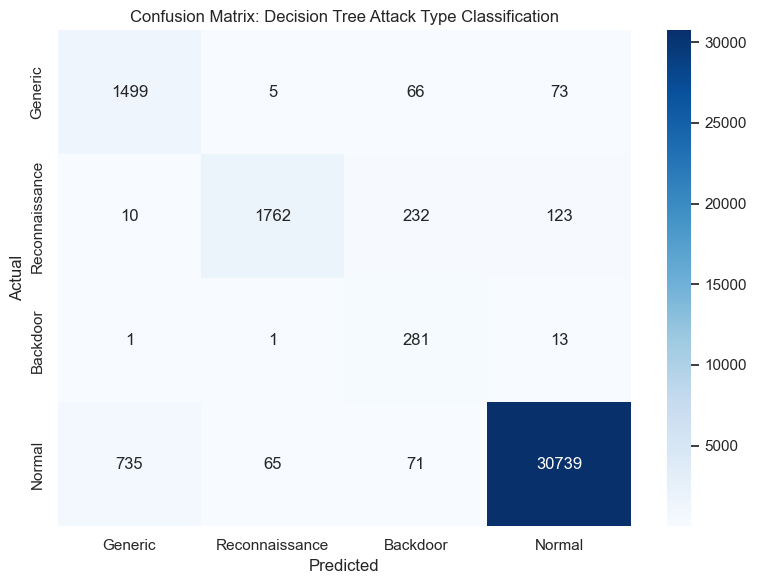

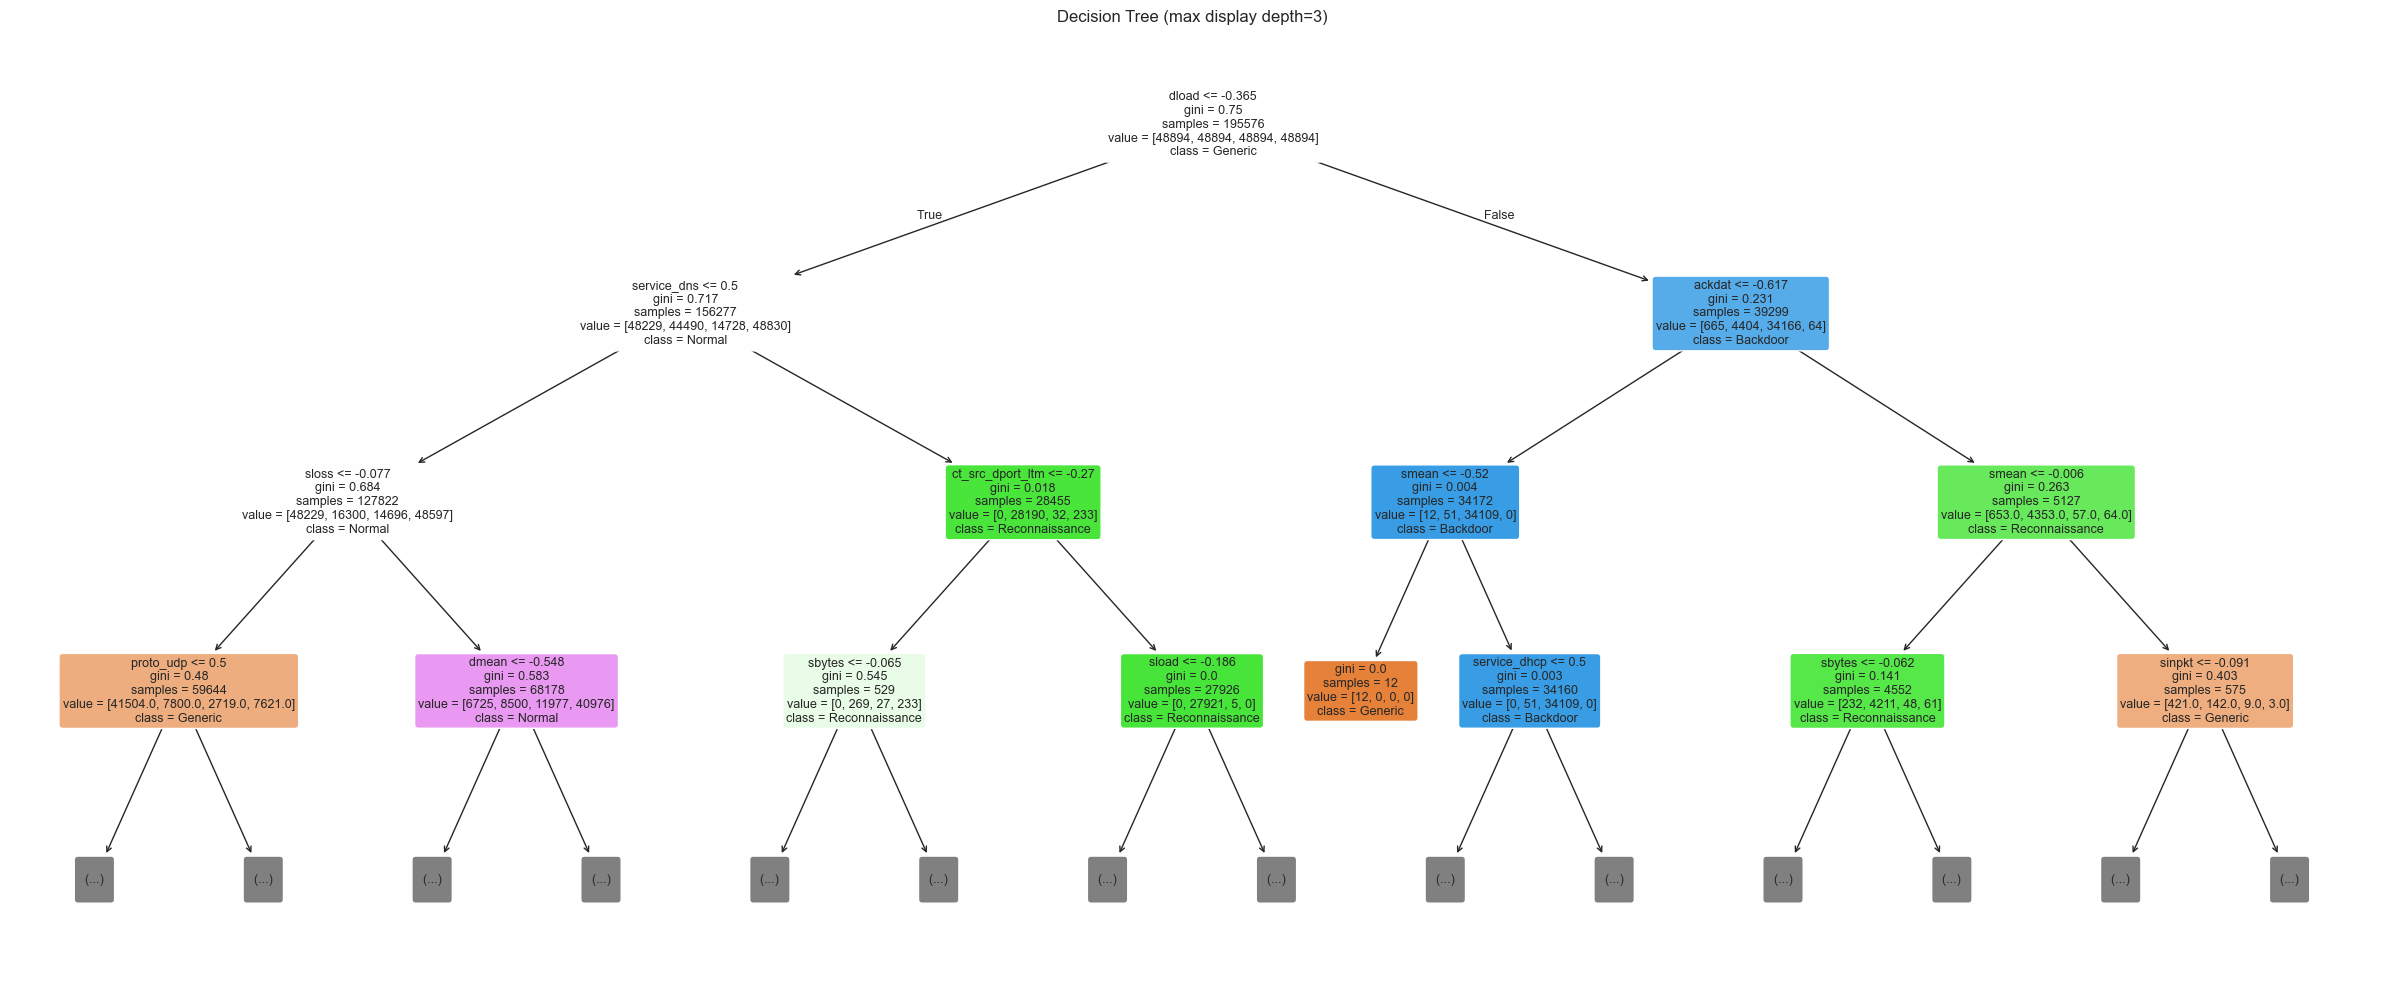

C:\Users\Christopher Chong\AppData\Local\Temp\ipykernel_27232\3444366965.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette="Blues_r")


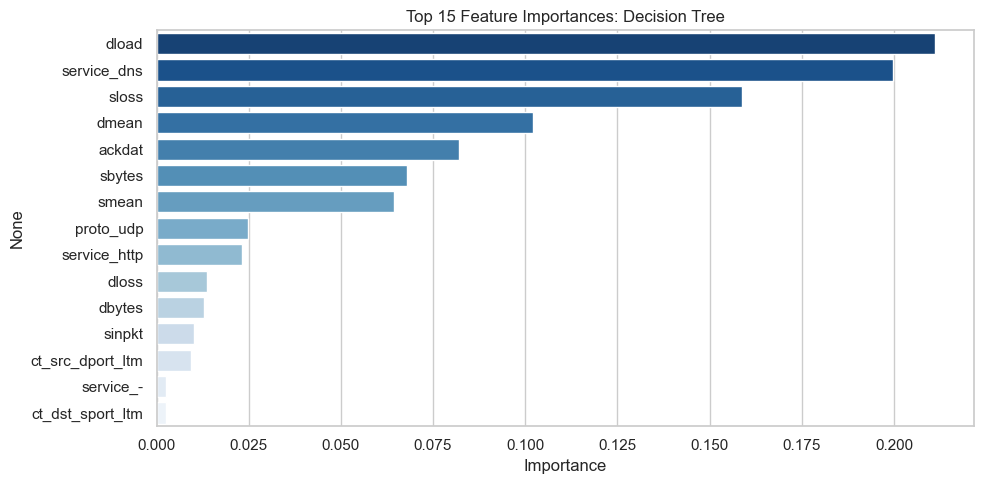

In [61]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Train Decision Tree for attack type classification
dt_attack_clf = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced",
    max_depth=10
)
dt_attack_clf.fit(X_train_smote, y_train_smote)

# Predict and evaluate
y_pred_dt_attack = dt_attack_clf.predict(X_test_filtered)

print("Attack Type Classification: DecisionTreeClassifier")
print(f"Accuracy: {accuracy_score(y_test_filtered, y_pred_dt_attack):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test_filtered, y_pred_dt_attack):.4f}")

print("\nClassification report:")
print(classification_report(y_test_filtered, y_pred_dt_attack, zero_division=0))

cm_dt_attack = confusion_matrix(y_test_filtered, y_pred_dt_attack, labels=attack_types)
print("Confusion matrix:")
print(cm_dt_attack)

# ROC-AUC and PR-AUC (multiclass OvR, macro average)
dt_proba = dt_attack_clf.predict_proba(X_test_filtered)
y_test_bin_dt = label_binarize(y_test_filtered, classes=dt_attack_clf.classes_)
print(f"ROC-AUC (macro OvR): {roc_auc_score(y_test_bin_dt, dt_proba, average='macro'):.4f}")
print(f"PR-AUC  (macro OvR): {average_precision_score(y_test_bin_dt, dt_proba, average='macro'):.4f}")

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt_attack, annot=True, fmt="d", cmap="Blues",
            xticklabels=attack_types, yticklabels=attack_types)
plt.title("Confusion Matrix: Decision Tree Attack Type Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Plot the decision tree (limited depth for readability)
plt.figure(figsize=(24, 10))
plot_tree(dt_attack_clf, max_depth=3, feature_names=X_train_smote.columns,
          class_names=attack_types, filled=True, rounded=True, fontsize=9)
plt.title("Decision Tree (max display depth=3)")
plt.tight_layout()
plt.show()

# Feature importances
importances = pd.Series(dt_attack_clf.feature_importances_, index=X_train_smote.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_features.values, y=top_features.index, palette="Blues_r")
plt.title("Top 15 Feature Importances: Decision Tree")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

c:\Users\Christopher Chong\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:22:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "scale_pos_weight", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Attack Type Classification: XGBClassifier
Accuracy: 0.9780
Balanced Accuracy: 0.8916

Classification report:
                precision    recall  f1-score   support

      Backdoor       0.47      0.85      0.60       296
       Generic       0.90      0.89      0.90      1643
        Normal       0.99      0.99      0.99     31610
Reconnaissance       0.95      0.83      0.89      2127

      accuracy                           0.98     35676
     macro avg       0.83      0.89      0.84     35676
  weighted avg       0.98      0.98      0.98     35676

Confusion matrix:
[[ 1462    17    46   118]
 [   20  1776   225   106]
 [    6    27   251    12]
 [  136    56    15 31403]]
ROC-AUC (macro OvR): 0.9950
PR-AUC  (macro OvR): 0.8586


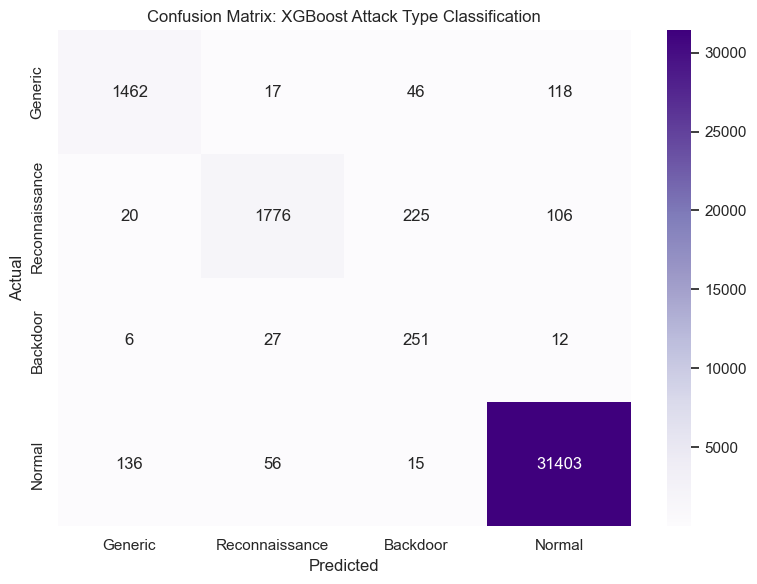

C:\Users\Christopher Chong\AppData\Local\Temp\ipykernel_27232\1527147656.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features_xgb.values, y=top_features_xgb.index, palette="Purples_r")


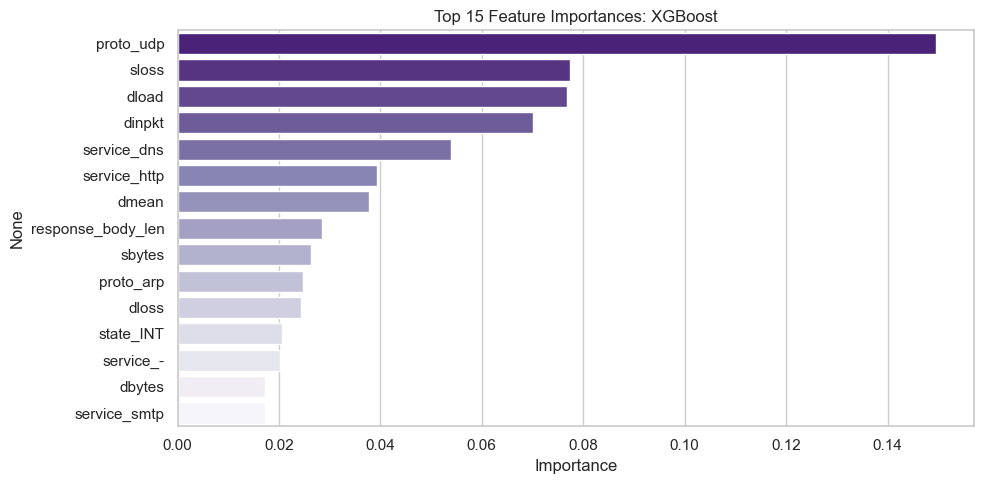

In [62]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# Train XGBoost for attack type classification
xgb_attack_clf = XGBClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=1,
    use_label_encoder=False,
    eval_metric='mlogloss'
)
le = LabelEncoder()
le.fit(attack_types)

y_train_encoded = le.transform(y_train_smote)
y_test_encoded = le.transform(y_test_filtered)

xgb_attack_clf.fit(X_train_smote, y_train_encoded)

# Predict and evaluate
y_pred_xgb_attack = le.inverse_transform(xgb_attack_clf.predict(X_test_filtered))

print("Attack Type Classification: XGBClassifier")
print(f"Accuracy: {accuracy_score(y_test_filtered, y_pred_xgb_attack):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test_filtered, y_pred_xgb_attack):.4f}")

print("\nClassification report:")
print(classification_report(y_test_filtered, y_pred_xgb_attack, zero_division=0))

cm_xgb_attack = confusion_matrix(y_test_filtered, y_pred_xgb_attack, labels=attack_types)
print("Confusion matrix:")
print(cm_xgb_attack)

# ROC-AUC and PR-AUC (multiclass OvR, macro average)
# XGBoost proba columns follow le.classes_ order
xgb_proba = xgb_attack_clf.predict_proba(X_test_filtered)
y_test_bin_xgb = label_binarize(y_test_encoded, classes=range(len(le.classes_)))
print(f"ROC-AUC (macro OvR): {roc_auc_score(y_test_bin_xgb, xgb_proba, average='macro'):.4f}")
print(f"PR-AUC  (macro OvR): {average_precision_score(y_test_bin_xgb, xgb_proba, average='macro'):.4f}")

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb_attack, annot=True, fmt="d", cmap="Purples",
            xticklabels=attack_types, yticklabels=attack_types)
plt.title("Confusion Matrix: XGBoost Attack Type Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Feature importances
importances_xgb = pd.Series(xgb_attack_clf.feature_importances_, index=X_train_smote.columns)
top_features_xgb = importances_xgb.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_features_xgb.values, y=top_features_xgb.index, palette="Purples_r")
plt.title("Top 15 Feature Importances: XGBoost")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

c:\Users\Christopher Chong\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 1, 128)         │       161,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,900 (831.64 KB)

 Trainable params: 212,900 (831.64 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
688/688 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8027 - loss: 0.5410 - val_accuracy: 0.8308 - val_loss: 0.6153
Epoch 2/20
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8757 - loss: 0.3613 - val_accuracy: 0.8420 - val_loss: 0.4777
Epoch 3/20
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8835 - loss: 0.3277 - val_accuracy: 0.8392 - val_loss: 0.5130
Epoch 4/20
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8908 - loss: 0.3038 - val_accuracy: 0.8450 - val_loss: 0.4608
Epoch 5/20
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8974 - loss: 0.2849 - val_accuracy: 0.8471 - val_loss: 0.4448
Epoch 6/20
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9039 - loss: 0.2696 - val_accuracy: 0.8468 - val_loss: 0.4520
Epoch 7/20
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9079 - loss: 0.2585 - val_accuracy: 0.8486 - val_loss: 0.4447
Epoch 8/20
688/688 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9126 - loss: 0.2478 - val_accuracy: 0.

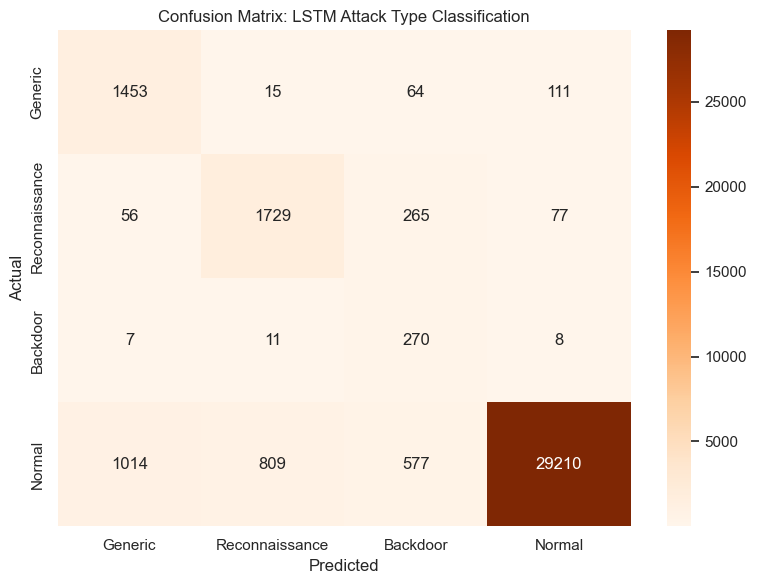

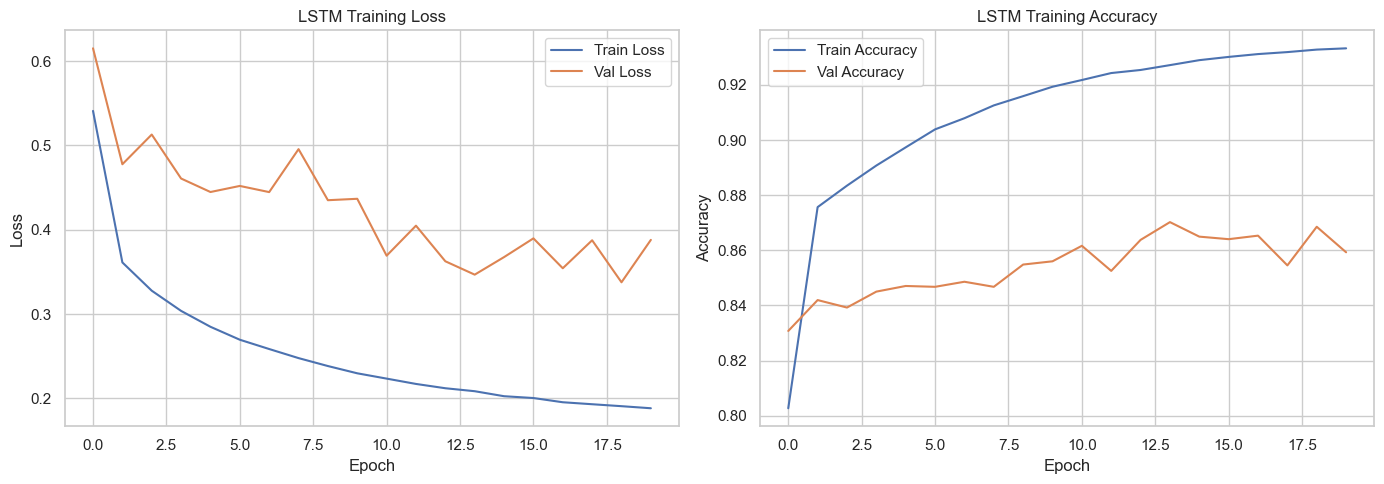

In [63]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix

# Prepare data: convert to numeric dtype and reshape for LSTM (samples, timesteps, features)
X_train_lstm = X_train_smote.to_numpy(dtype=np.float32).reshape(
    (X_train_smote.shape[0], 1, X_train_smote.shape[1])
)
X_test_lstm = X_test_filtered.to_numpy(dtype=np.float32).reshape(
    (X_test_filtered.shape[0], 1, X_test_filtered.shape[1])
)

# Encode labels
le_lstm = LabelEncoder()
le_lstm.fit(attack_types)
y_train_lstm = to_categorical(
    le_lstm.transform(y_train_smote), num_classes=len(attack_types)
).astype(np.float32)
y_test_lstm_encoded = le_lstm.transform(y_test_filtered)

# Build LSTM model
lstm_model = Sequential([
    LSTM(128, input_shape=(1, X_train_smote.shape[1]), return_sequences=True),
    Dropout(0.3),
    LSTM(64),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(len(attack_types), activation='softmax')
])

lstm_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
lstm_model.summary()

# Train
history = lstm_model.fit(
    X_train_lstm, y_train_lstm,
    epochs=20,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

# Predict
y_pred_lstm_probs = lstm_model.predict(X_test_lstm)
y_pred_lstm_encoded = np.argmax(y_pred_lstm_probs, axis=1)
y_pred_lstm = le_lstm.inverse_transform(y_pred_lstm_encoded)

print("Attack Type Classification: LSTM")
print(f"Accuracy: {accuracy_score(y_test_filtered, y_pred_lstm):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test_filtered, y_pred_lstm):.4f}")
print("\nClassification report:")
print(classification_report(y_test_filtered, y_pred_lstm, zero_division=0))

# ROC-AUC and PR-AUC (multiclass OvR, macro average)
# y_pred_lstm_probs already contains per-class probabilities from softmax
y_test_bin_lstm = label_binarize(y_test_lstm_encoded, classes=range(len(attack_types)))
print(f"ROC-AUC (macro OvR): {roc_auc_score(y_test_bin_lstm, y_pred_lstm_probs, average='macro'):.4f}")
print(f"PR-AUC  (macro OvR): {average_precision_score(y_test_bin_lstm, y_pred_lstm_probs, average='macro'):.4f}")

cm_lstm = confusion_matrix(y_test_filtered, y_pred_lstm, labels=attack_types)
print("Confusion matrix:")
print(cm_lstm)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lstm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=attack_types, yticklabels=attack_types)
plt.title("Confusion Matrix: LSTM Attack Type Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('LSTM Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('LSTM Training Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Summary: All Models Comparison



from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)

# Each entry: (name, y_pred, y_proba, y_test_binarized)
# All metrics use macro averaging to treat each attack class equally
models = [
    ("Random Forest",   y_pred_attack,     rf_proba,          y_test_bin),
    ("Decision Tree",   y_pred_dt_attack,  dt_proba,          y_test_bin_dt),
    ("XGBoost",         y_pred_xgb_attack, xgb_proba,         y_test_bin_xgb),
    ("LSTM",            y_pred_lstm,       y_pred_lstm_probs, y_test_bin_lstm),
]

rows = []
for name, y_p, y_prob, y_bin in models:
    rows.append({
        "Model":      name,
        "Precision":  precision_score(y_test_filtered, y_p, average="macro", zero_division=0),
        "Recall":     recall_score(y_test_filtered, y_p, average="macro", zero_division=0),
        "F1":         f1_score(y_test_filtered, y_p, average="macro", zero_division=0),
        "ROC-AUC":    roc_auc_score(y_bin, y_prob, average="macro"),
        "PR-AUC":     average_precision_score(y_bin, y_prob, average="macro"),
    })

summary = pd.DataFrame(rows).set_index("Model").round(4)
print(" Model Comparison Summary (macro-averaged, test set)")
print("all metrics are macro-averaged across 4 classes (Backdoor, Generic, Normal, Reconnaissance)")
print("SMOTE applied to training set only, test set reflects true class distribution")
display(summary)


=== Model Comparison Summary (macro-averaged, test set) ===
Note: all metrics are macro-averaged across 4 classes (Backdoor, Generic, Normal, Reconnaissance)
SMOTE applied to training set only — test set reflects true class distribution


,Precision,Recall,F1,ROC-AUC,PR-AUC
Model,,,,,
Random Forest,0.8275,0.8974,0.8510,0.9917,0.8303
Decision Tree,0.7636,0.9156,0.8095,0.9814,0.8450
XGBoost,0.8267,0.8916,0.8445,0.9950,0.8586
LSTM,0.6179,0.8834,0.6895,0.9794,0.7481
